In [11]:
import psycopg
from tabulate import tabulate
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analyse


## Verbindung zur Datenbank herstellen

In [12]:
connection = psycopg.connect(
    dbname='defaultdb',
    user='root',
    host='cockroach',
    port='26257',
    sslmode='disable'
)

cursor = connection.cursor()

## Hypothese 1: Kürzere Pitstopzeiten führen zu besseren Fahrerplatzierungen

### Durchschnittliche Pitstopzeiten je Fahrer
Im ersten Schritt werden für jeden Fahrer die durchschnittlichen Boxenstoppzeiten im Jahr 2024 berechnet. Hierzu werden die Tabellen pit_stops und races verknüpft. Um Ausreißer durch ungewöhnlich lange Stopps zu vermeiden, werden nur Boxenstopps mit einer Dauer unter 40 Sekunden berücksichtigt. Die durchschnittlichen Zeiten werden in Sekunden umgerechnet, gruppiert nach Fahrer und nach der Durchschnittszeit sortiert ausgegeben. Die Daten werden außerdem in einem DataFrame gespeichert, um sie später weiterzuverarbeiten.

In [13]:
cursor.execute("""
    SELECT
        ps.driver_id as driver_id,
        AVG(ps.milliseconds) / 1000 AS avg_pitstop_time
    FROM pit_stops ps
    JOIN races r
        ON ps.race_id = r.id
    WHERE r.year = 2024
    AND ps.milliseconds < 40000
    GROUP BY ps.driver_id
    ORDER BY avg_pitstop_time;
""")

rows = cursor.fetchall()
headers = [desc[0] for desc in cursor.description]

print(tabulate(rows, headers=headers, tablefmt="psql"))

avg_pit_by_driver = pd.DataFrame(rows, columns=[desc[0] for desc in cursor.description])

+-------------+--------------------+
|   driver_id |   avg_pitstop_time |
|-------------+--------------------|
|         862 |            22.08   |
|         839 |            23.6917 |
|         846 |            23.7298 |
|         844 |            23.8676 |
|         852 |            23.9989 |
|           1 |            24.0142 |
|         830 |            24.0767 |
|         857 |            24.1068 |
|         861 |            24.1239 |
|         815 |            24.1417 |
|         832 |            24.17   |
|         822 |            24.3478 |
|         840 |            24.3917 |
|         817 |            24.43   |
|         847 |            24.4864 |
|           4 |            24.6107 |
|         842 |            24.8443 |
|         858 |            24.9765 |
|         825 |            25.2509 |
|         807 |            25.343  |
|         855 |            25.5133 |
|         848 |            25.6392 |
|         859 |            25.7551 |
|         860 |            26.496  |
+

### Fahrerplatzierung am Saisonende
Im zweiten Schritt werden die finalen Fahrerplatzierungen des Jahres 2024 abgerufen. Dabei wird die Tabelle driver_standings mit der Tabelle races verknüpft, um die Ergebnisse der letzten Runde des Jahres zu erhalten. Die Daten werden nach der Position sortiert ausgegeben und in einem DataFrame gespeichert. So steht für jeden Fahrer die Endplatzierung der Saison bereit.

In [14]:
cursor.execute("""
    SELECT
        ds.driver_id,
        ds.position
    FROM driver_standings ds
    JOIN races r ON ds.race_id = r.id
    WHERE r.year = 2024
      AND r.round = (
          SELECT MAX(r2.round)
          FROM races r2
          WHERE r2.year = 2024
      )
    ORDER BY ds.position;
""")

rows = cursor.fetchall()
headers = [desc[0] for desc in cursor.description]

print(tabulate(rows, headers=headers, tablefmt="psql"))

final_driver_standings = pd.DataFrame(rows, columns=[desc[0] for desc in cursor.description])


+-------------+------------+
|   driver_id |   position |
|-------------+------------|
|         830 |          1 |
|         846 |          2 |
|         844 |          3 |
|         857 |          4 |
|         832 |          5 |
|         847 |          6 |
|           1 |          7 |
|         815 |          8 |
|           4 |          9 |
|         842 |         10 |
|         807 |         11 |
|         852 |         12 |
|         840 |         13 |
|         839 |         14 |
|         825 |         15 |
|         848 |         16 |
|         817 |         17 |
|         860 |         18 |
|         861 |         19 |
|         855 |         20 |
|         859 |         21 |
|         822 |         22 |
|         858 |         23 |
|         862 |         24 |
+-------------+------------+


### Visualisierung
Im letzten Schritt werden die beiden DataFrames mit den durchschnittlichen Boxenstoppzeiten und den finalen Fahrerplatzierungen zusammengeführt. Dabei wird sichergestellt, dass die Spalten korrekt als numerische Werte interpretiert werden. Anschließend wird ein Streudiagramm mit Regressionslinie erstellt, um den möglichen Zusammenhang zwischen der Platzierung im Fahrer-Standing und der durchschnittlichen Boxenstoppzeit sichtbar zu machen. Die Grafik dient dazu, die theoretische Annahme empirisch zu überprüfen.

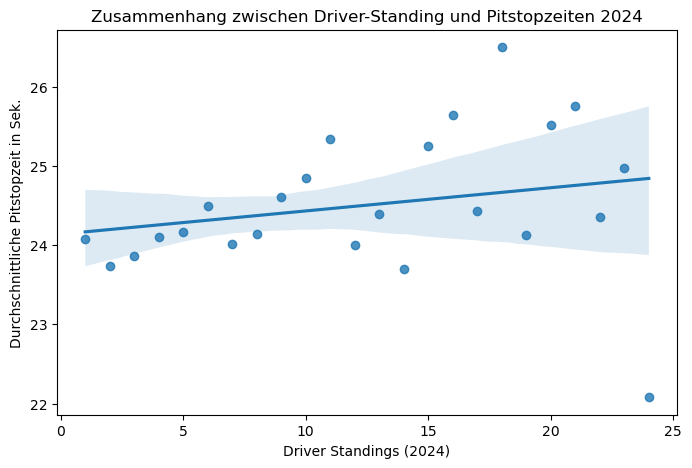

In [15]:
# Merge und Plot
merged_df = pd.merge(final_driver_standings, avg_pit_by_driver, on="driver_id")
merged_df["position"] = merged_df["position"].astype(float)
merged_df["avg_pitstop_time"] = merged_df["avg_pitstop_time"].astype(float)
plt.figure(figsize=(8,5))
sns.regplot(data=merged_df, x="position", y="avg_pitstop_time", scatter=True, ci=95)
plt.xlabel("Driver Standings (2024)")
plt.ylabel("Durchschnittliche Pitstopzeit in Sek.")
plt.title("Zusammenhang zwischen Driver-Standing und Pitstopzeiten 2024")
plt.show()

## Hypothese 2: Kürzere Pitstopzeiten führen zu besseren Konstrukteursplatzierungen

### Durchschnittliche Pitstopzeiten je Team
Zunächst werden die durchschnittlichen Boxenstoppzeiten pro Konstrukteur (Team) für die Saison 2024 berechnet. Um Ausreißer zu vermeiden, werden wie auch vorher nur Stopps berücksichtigt, die unter 40 Sekunden dauerten.

In [16]:
cursor.execute("""
    SELECT
        c.id as constructor_id,
        AVG(ps.milliseconds) / 1000 AS avg_pitstop_time
    FROM pit_stops ps
    JOIN results res
        ON ps.race_id = res.race_id AND ps.driver_id = res.driver_id
    JOIN races r
        ON ps.race_id = r.id
    JOIN constructors c
        ON res.constructor_id = c.id
    WHERE r.year = 2024
    AND ps.milliseconds < 40000
    GROUP BY c.id, c.name
    ORDER BY avg_pitstop_time;
""")

rows = cursor.fetchall()
headers = [desc[0] for desc in cursor.description]

print(tabulate(rows, headers=headers, tablefmt="psql"))

avg_pit_by_team = pd.DataFrame(rows, columns=[desc[0] for desc in cursor.description])

+------------------+--------------------+
|   constructor_id |   avg_pitstop_time |
|------------------+--------------------|
|                1 |            23.9208 |
|                6 |            23.9916 |
|                9 |            24.1121 |
|              214 |            24.2209 |
|              131 |            24.2503 |
|              215 |            24.4475 |
|              117 |            24.5012 |
|               15 |            24.985  |
|                3 |            25.2047 |
|              210 |            25.3747 |
+------------------+--------------------+


### Teamplatzierung am Saisonende
Im zweiten Schritt wird die finale Platzierung der Konstrukteure ermittelt. Dazu wird der Stand aus dem letzten Rennen der Saison 2024 verwendet, also der Endstand in der Konstrukteursmeisterschaft.

In [17]:
cursor.execute("""
    SELECT
        cs.constructor_id,
        cs.position
    FROM constructor_standings cs
    JOIN constructors c ON cs.constructor_id = c.id
    JOIN races r ON cs.race_id = r.id
    WHERE r.year = 2024
      AND r.round = (
          SELECT MAX(r2.round)
          FROM races r2
          WHERE r2.year = 2024
      )
    ORDER BY cs.position;
""")

rows = cursor.fetchall()
headers = [desc[0] for desc in cursor.description]

print(tabulate(rows, headers=headers, tablefmt="psql"))

final_standings = pd.DataFrame(rows, columns=[desc[0] for desc in cursor.description])

+------------------+------------+
|   constructor_id |   position |
|------------------+------------|
|                1 |          1 |
|                6 |          2 |
|                9 |          3 |
|              131 |          4 |
|              117 |          5 |
|              214 |          6 |
|              210 |          7 |
|              215 |          8 |
|                3 |          9 |
|               15 |         10 |
+------------------+------------+


### 5.4.3 Visualisierung
Die beiden Datensätze werden anhand der Konstrukteurs-IDs zusammengeführt. Anschließend wird mit einem Regressionsplot dargestellt, wie sich die durchschnittliche Boxenstoppzeit eines Teams auf seine Platzierung auswirkt.

   constructor_id  position  avg_pitstop_time
0               1       1.0         23.920753
1               6       2.0         23.991554
2               9       3.0         24.112051
3             131       4.0         24.250321
4             117       5.0         24.501213


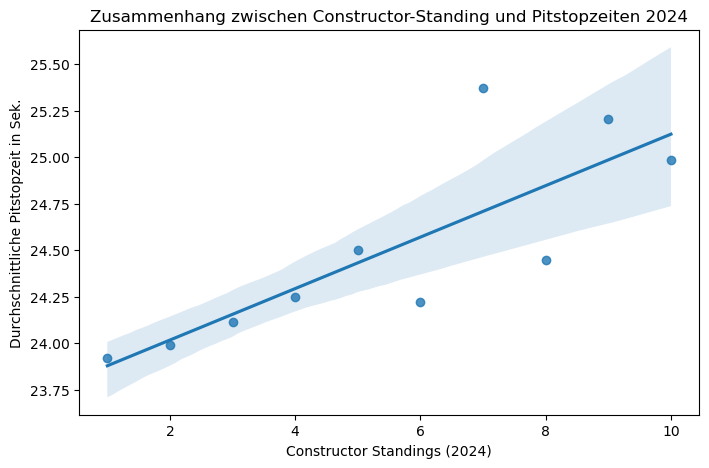

In [18]:
# Merge und Plot
merged_df = pd.merge(final_standings, avg_pit_by_team, on="constructor_id")
merged_df["position"] = merged_df["position"].astype(float)
merged_df["avg_pitstop_time"] = merged_df["avg_pitstop_time"].astype(float)
print(merged_df.head())
plt.figure(figsize=(8,5))
sns.regplot(data=merged_df, x="position", y="avg_pitstop_time", scatter=True, ci=95)
plt.xlabel("Constructor Standings (2024)")
plt.ylabel("Durchschnittliche Pitstopzeit in Sek.")
plt.title("Zusammenhang zwischen Constructor-Standing und Pitstopzeiten 2024")
plt.show()

## Verbindung zur Datenbank schließen

In [19]:
cursor.close()
connection.close()